In [1]:
import numpy as np
import pandas as pd

import dask.dataframe as dd
import dask.array as da
import dask.bag as db

In [2]:
b = db.from_sequence([1, 2, 3, 4, 5, 6, 2, 1], npartitions=2)
b

dask.bag<from_sequence, npartitions=2>

In [3]:
b.compute()

[1, 2, 3, 4, 5, 6, 2, 1]

In [4]:
b.filter(lambda x: x % 2)

dask.bag<filter-lambda, npartitions=2>

In [5]:
b.filter(lambda x: x % 2).compute()

[1, 3, 5, 1]

In [6]:
b.distinct()

dask.bag<distinct-aggregate, npartitions=1>

In [7]:
b.distinct().compute()

[1, 2, 3, 4, 5, 6]

In [8]:
c = db.zip(b, b.map(lambda x: x * 10))
c

dask.bag<zip, npartitions=2>

In [9]:
c.compute()

[(1, 10), (2, 20), (3, 30), (4, 40), (5, 50), (6, 60), (2, 20), (1, 10)]

In [10]:
c.dask

HighLevelGraph with 3 layers.
<dask.highlevelgraph.HighLevelGraph object at 0x702f59342f30>
 0. from_sequence-13259725da943d601816659f766f5097
 1. lambda-327f6d19e9fb766e7155234ef192a9f4
 2. zip-f9c320b33c7184a7c70acf998b05ef2a

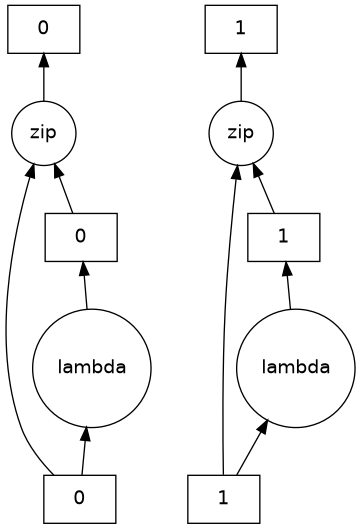

In [11]:
c.visualize()